In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_excel("Kompilasi Data 2.xlsx")

In [3]:
df.shape

(38, 11)

In [4]:
df.head()

,Provinsi,IPM,Infrastruktur_Desa,IMDI,Persen_Ecommerce,Jumlah_UMKM,nilai_tambah,Penetrasi_Internet,Pelatihan_TIK,Level_TIK,Pembayaran_Digital
0,Aceh,74.03,98.864334,50.50,37.65,108507,5086801,75.99,5.12,198.69,0.99
1,Sumatera Utara,74.02,96.613774,49.05,35.38,123911,7957689,73.15,2.72,172.37,4.06
2,Sumatera Barat,74.49,98.055988,47.62,28.75,88053,4567033,75.14,5.56,194.63,3.08
3,Riau,74.79,98.395722,47.42,36.93,54425,3494581,82.49,2.57,156.56,5.66
4,Jambi,73.43,98.296530,47.10,33.90,31268,2065021,85.91,3.65,150.80,4.12


In [5]:
df.tail()

,Provinsi,IPM,Infrastruktur_Desa,IMDI,Persen_Ecommerce,Jumlah_UMKM,nilai_tambah,Penetrasi_Internet,Pelatihan_TIK,Level_TIK,Pembayaran_Digital
33,Papua Barat Daya,68.63,92.329545,40.46,24.68,2861,272521,74.43,5.26,156.89,2.57
34,Papua,73.00,88.046647,40.11,23.29,7499,398165,74.11,7.02,172.14,11.27
35,Papua Selatan,67.90,84.782609,38.32,28.98,4931,363652,73.21,2.91,236.01,1.29
36,Papua Tengah,59.75,27.897351,36.66,28.78,3828,290986,73.28,0.56,156.26,1.75
37,Papua Pegunungan,53.42,36.712225,32.48,2.70,587,51030,57.30,2.89,151.42,0.00


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38 entries, 0 to 37
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Provinsi            38 non-null     object 
 1   IPM                 38 non-null     float64
 2   Infrastruktur_Desa  38 non-null     float64
 3   IMDI                38 non-null     float64
 4   Persen_Ecommerce    38 non-null     float64
 5   Jumlah_UMKM         38 non-null     int64  
 6   nilai_tambah        38 non-null     int64  
 7   Penetrasi_Internet  38 non-null     float64
 8   Pelatihan_TIK       38 non-null     float64
 9   Level_TIK           38 non-null     float64
 10  Pembayaran_Digital  38 non-null     float64
dtypes: float64(8), int64(2), object(1)
memory usage: 3.4+ KB


In [7]:
#finding missing value
df.isnull().sum()

Provinsi              0
IPM                   0
Infrastruktur_Desa    0
IMDI                  0
Persen_Ecommerce      0
Jumlah_UMKM           0
nilai_tambah          0
Penetrasi_Internet    0
Pelatihan_TIK         0
Level_TIK             0
Pembayaran_Digital    0
dtype: int64

In [8]:
df.isnull().sum()/df.shape[0]*100

Provinsi              0.0
IPM                   0.0
Infrastruktur_Desa    0.0
IMDI                  0.0
Persen_Ecommerce      0.0
Jumlah_UMKM           0.0
nilai_tambah          0.0
Penetrasi_Internet    0.0
Pelatihan_TIK         0.0
Level_TIK             0.0
Pembayaran_Digital    0.0
dtype: float64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
#identify garbage value (ngecek kemungkinan adanya typo atau rare nilai yg tidak sesuai dgn konsep data)
for col in df.select_dtypes(include="object").columns:
    print(f"\nColumn: {col}")
    print(f"Unique values: {df[col].nunique()}")
    print("Top values:")
    print(df[col].value_counts().head(10))
    print("Rare values:")
    print(df[col].value_counts()[df[col].value_counts() <= 2].head(20))
    print("-" * 50)


Column: Provinsi
Unique values: 38
Top values:
Provinsi
Aceh                    1
Sumatera Utara          1
Sumatera Barat          1
Riau                    1
Jambi                   1
Sumatera Selatan        1
Bengkulu                1
Lampung                 1
Kep. Bangka Belitung    1
Kepulauan Riau          1
Name: count, dtype: int64
Rare values:
Provinsi
Aceh                    1
Sumatera Utara          1
Sumatera Barat          1
Riau                    1
Jambi                   1
Sumatera Selatan        1
Bengkulu                1
Lampung                 1
Kep. Bangka Belitung    1
Kepulauan Riau          1
DKI Jakarta             1
Jawa Barat              1
Jawa Tengah             1
D.I. Yogyakarta         1
Jawa Timur              1
Banten                  1
Bali                    1
Nusa Tenggara Barat     1
Nusa Tenggara Timur     1
Kalimantan Barat        1
Name: count, dtype: int64
--------------------------------------------------


In [11]:
df.describe(include="object")

,Provinsi
count,38
unique,38
top,Aceh
freq,1


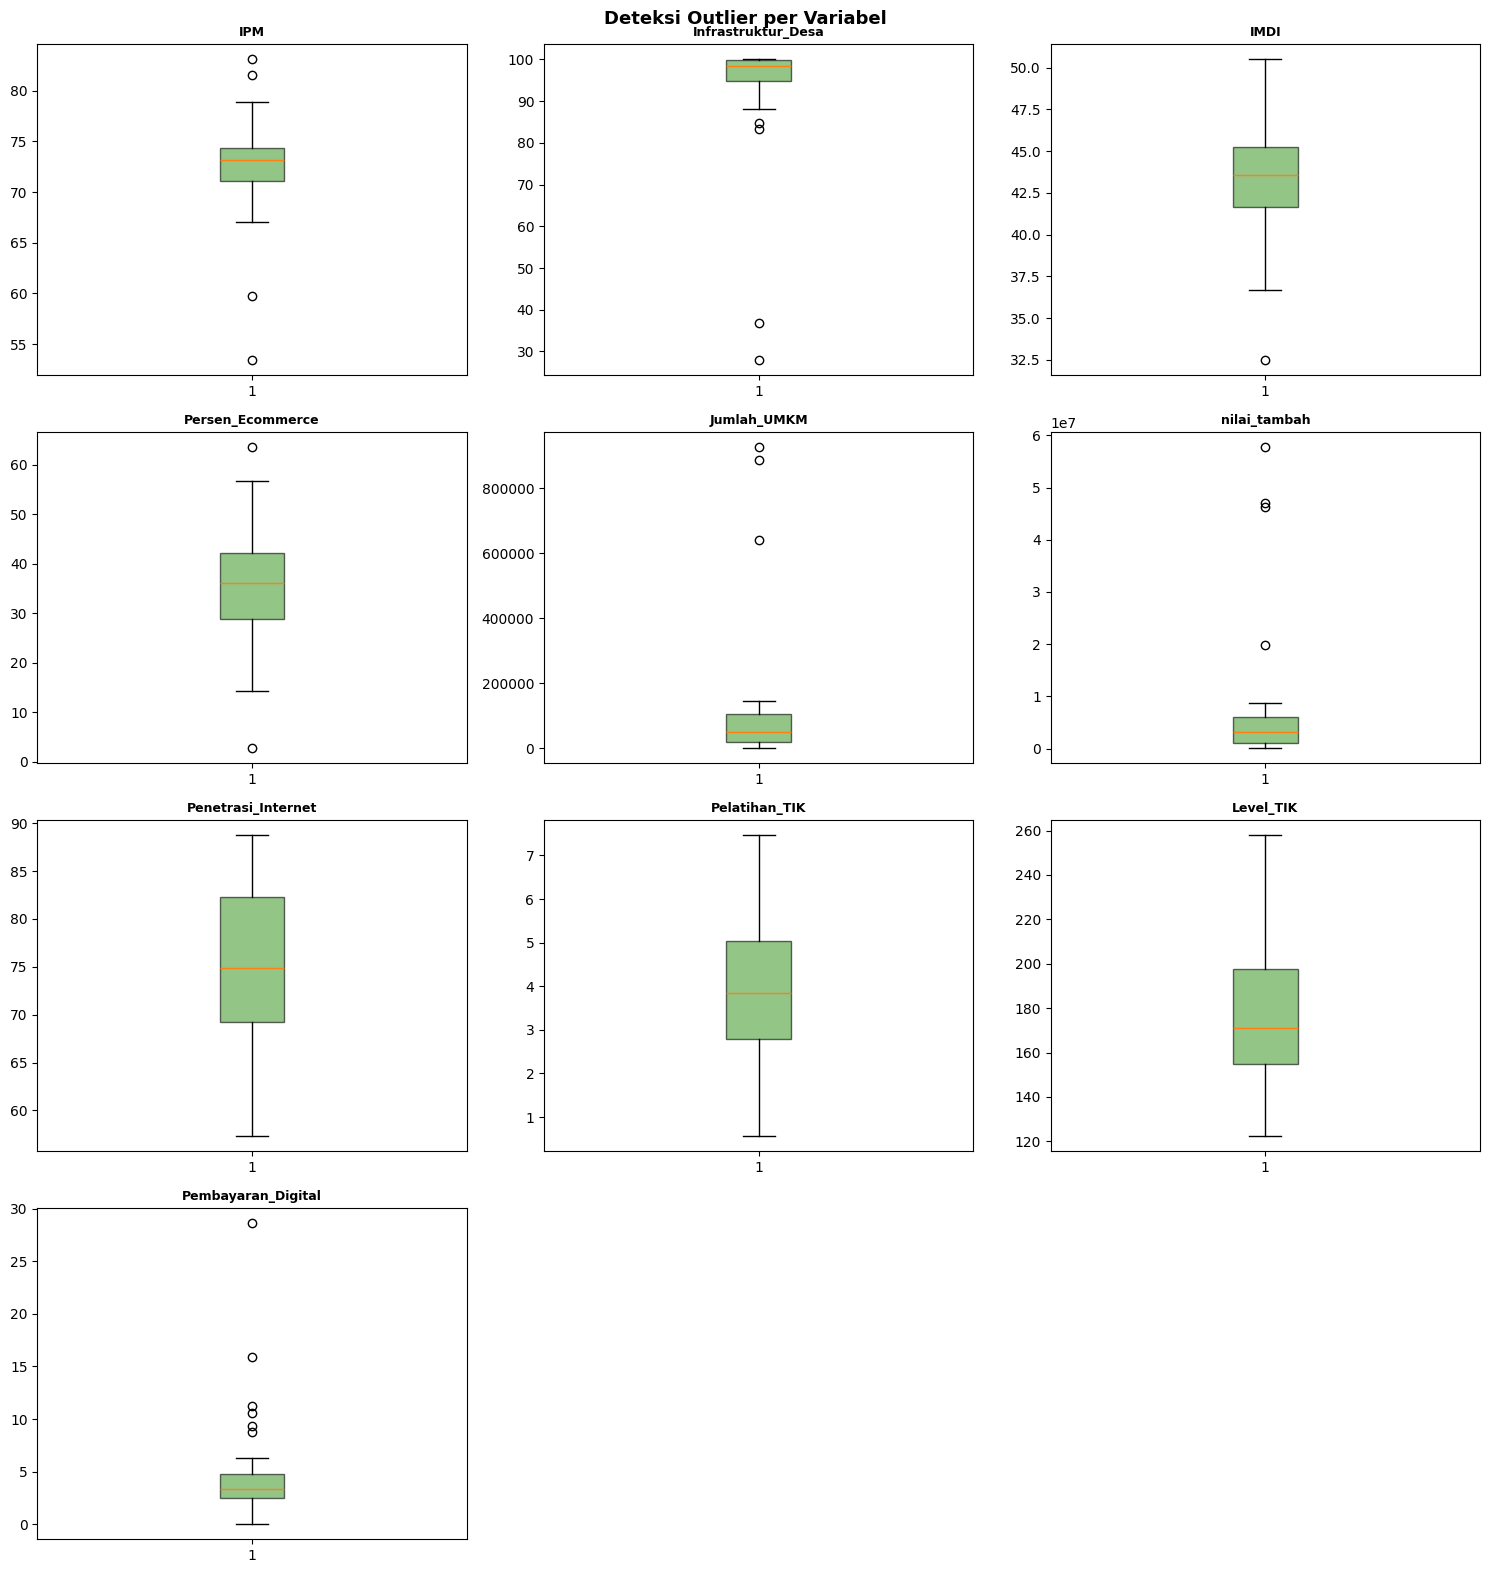

In [12]:
#deteksi outlier dengan boxplot
df_num = df.drop(columns=['Provinsi'])

cols = df_num.columns
n_cols = 3
n_rows = -(-len(cols) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(cols):
    axes[i].boxplot(df_num[col], patch_artist=True,
                    boxprops=dict(facecolor='#4C9F38', alpha=0.6))
    axes[i].set_title(col, fontsize=9, fontweight='bold')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Deteksi Outlier per Variabel', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

pengecilan skala, (jumlah umkm dan nilai tamnbah)

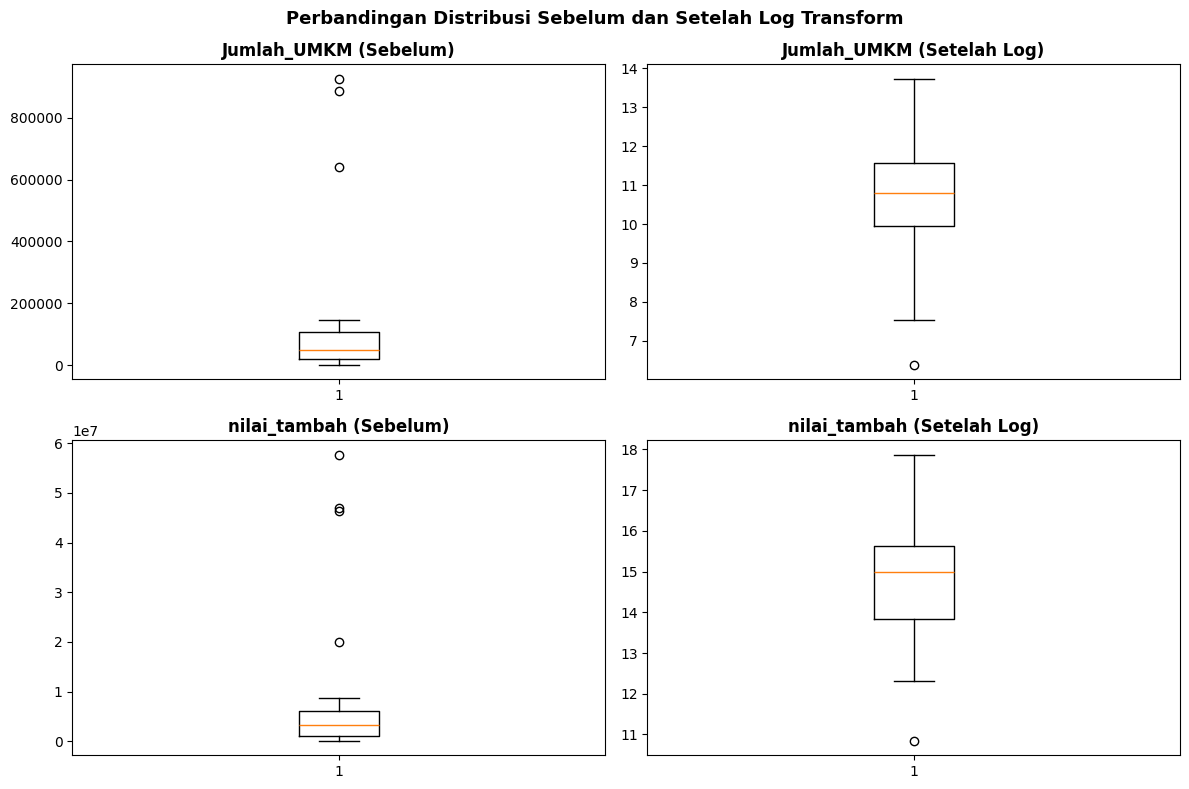


Sebelum Log Transform:
       Jumlah_UMKM  nilai_tambah
count       38.000  3.800000e+01
mean    116143.289  7.301559e+06
std     215817.568  1.336654e+07
min        587.000  5.103000e+04
25%      20746.750  1.024709e+06
50%      49199.000  3.203949e+06
75%     106311.750  6.088314e+06
max     925985.000  5.769454e+07

Setelah Log Transform:
       Jumlah_UMKM  nilai_tambah
count       38.000        38.000
mean        10.610        14.728
std          1.591         1.553
min          6.377        10.840
25%          9.940        13.840
50%         10.804        14.979
75%         11.573        15.622
max         13.739        17.871


In [13]:
# Log Transformation untuk variabel dengan outlier ekstrem
df_log = df.copy()
df_log['Jumlah_UMKM'] = np.log1p(df['Jumlah_UMKM'])
df_log['nilai_tambah'] = np.log1p(df['nilai_tambah'])

# Visualisasi perbandingan
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0,0].boxplot(df['Jumlah_UMKM'])
axes[0,0].set_title('Jumlah_UMKM (Sebelum)', fontweight='bold')

axes[0,1].boxplot(df_log['Jumlah_UMKM'])
axes[0,1].set_title('Jumlah_UMKM (Setelah Log)', fontweight='bold')

axes[1,0].boxplot(df['nilai_tambah'])
axes[1,0].set_title('nilai_tambah (Sebelum)', fontweight='bold')

axes[1,1].boxplot(df_log['nilai_tambah'])
axes[1,1].set_title('nilai_tambah (Setelah Log)', fontweight='bold')

plt.suptitle('Perbandingan Distribusi Sebelum dan Setelah Log Transform',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nSebelum Log Transform:")
print(df[['Jumlah_UMKM', 'nilai_tambah']].describe().round(3))
print("\nSetelah Log Transform:")
print(df_log[['Jumlah_UMKM', 'nilai_tambah']].describe().round(3))

outlier ekstrim di : 
Jumlah_UMKM, nilai_tambah, Pelatihan_TIK, Infrastruktur_Desa

In [14]:
#normalisasi data, using minmax and standard scaler

from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Pisahkan kolom provinsi
provinsi = df_log['Provinsi']
df_num = df_log.drop(columns=['Provinsi'])

# Standard Scaler
standard_scaler = StandardScaler()
df_standard = pd.DataFrame(
    standard_scaler.fit_transform(df_num),
    columns=df_num.columns
)
df_standard.insert(0, 'Provinsi', provinsi.values)

print("Standard Scaler:")
print(df_standard.describe().round(3))

X = df_standard.drop(columns=['Provinsi']).values

Standard Scaler:
          IPM  Infrastruktur_Desa    IMDI  Persen_Ecommerce  Jumlah_UMKM  \
count  38.000              38.000  38.000            38.000       38.000   
mean   -0.000               0.000   0.000            -0.000       -0.000   
std     1.013               1.013   1.013             1.013        1.013   
min    -3.732              -4.351  -3.297            -2.746       -2.696   
25%    -0.257               0.105  -0.511            -0.544       -0.427   
50%     0.156               0.335   0.072             0.081        0.123   
75%     0.385               0.436   0.576             0.594        0.613   
max     2.104               0.445   2.172             2.395        1.992   

       nilai_tambah  Penetrasi_Internet  Pelatihan_TIK  Level_TIK  \
count        38.000              38.000         38.000     38.000   
mean          0.000              -0.000          0.000     -0.000   
std           1.013               1.013          1.013      1.013   
min          -2.538   

In [15]:
# MinMax Scaler
minmax_scaler = MinMaxScaler()
df_minmax = pd.DataFrame(
    minmax_scaler.fit_transform(df_num),
    columns=df_num.columns
)
df_minmax.insert(0, 'Provinsi', provinsi.values)

print("MinMax Scaler:")
print(df_minmax.describe().round(3))

MinMax Scaler:
          IPM  Infrastruktur_Desa    IMDI  Persen_Ecommerce  Jumlah_UMKM  \
count  38.000              38.000  38.000            38.000       38.000   
mean    0.640               0.907   0.603             0.534        0.575   
std     0.174               0.211   0.185             0.197        0.216   
min     0.000               0.000   0.000             0.000        0.000   
25%     0.595               0.929   0.509             0.428        0.484   
50%     0.666               0.977   0.616             0.550        0.601   
75%     0.705               0.998   0.708             0.650        0.706   
max     1.000               1.000   1.000             1.000        1.000   

       nilai_tambah  Penetrasi_Internet  Pelatihan_TIK  Level_TIK  \
count        38.000              38.000         38.000     38.000   
mean          0.553               0.571          0.491      0.411   
std           0.221               0.266          0.213      0.249   
min           0.000     

komparasi minmax da standard

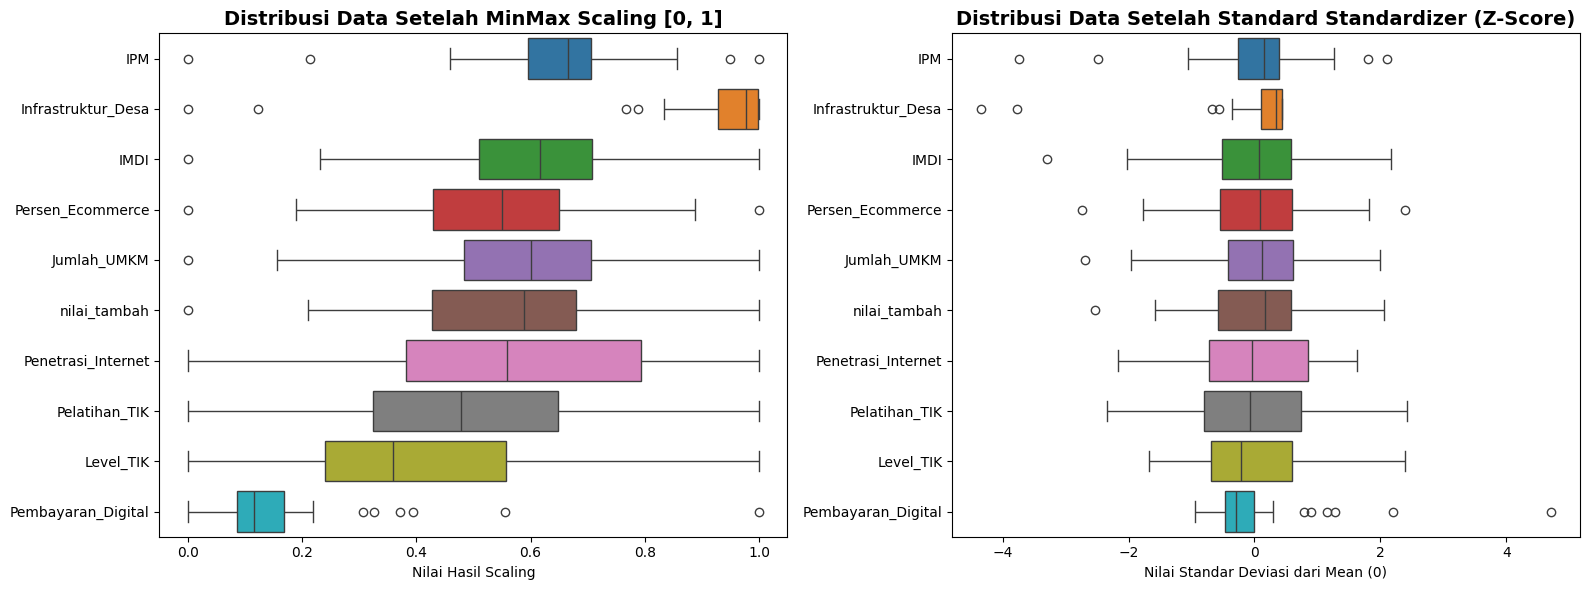

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(data=df_minmax.drop(columns=['Provinsi']), ax=axes[0], orient='h')
axes[0].set_title('Distribusi Data Setelah MinMax Scaling [0, 1]', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Nilai Hasil Scaling')

sns.boxplot(data=df_standard.drop(columns=['Provinsi']), ax=axes[1], orient='h')
axes[1].set_title('Distribusi Data Setelah Standard Standardizer (Z-Score)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Nilai Standar Deviasi dari Mean (0)')

plt.tight_layout()
plt.show()

In [17]:
df_num = df.drop(columns=['Provinsi'])

komparasi = pd.DataFrame(index=df_num.columns)

komparasi['MinMax_Min'] = df_minmax.drop(columns=['Provinsi']).min().round(3)
komparasi['MinMax_Mean'] = df_minmax.drop(columns=['Provinsi']).mean().round(3)
komparasi['MinMax_Max'] = df_minmax.drop(columns=['Provinsi']).max().round(3)

komparasi['StdScaler_Min'] = df_standard.drop(columns=['Provinsi']).min().round(3)
komparasi['StdScaler_Mean'] = df_standard.drop(columns=['Provinsi']).mean().round(3)
komparasi['StdScaler_Max'] = df_standard.drop(columns=['Provinsi']).max().round(3)

print("Tabel Komparasi")
komparasi

Tabel Komparasi


,MinMax_Min,MinMax_Mean,MinMax_Max,StdScaler_Min,StdScaler_Mean,StdScaler_Max
IPM,0.0,0.640,1.0,-3.732,-0.0,2.104
Infrastruktur_Desa,0.0,0.907,1.0,-4.351,0.0,0.445
IMDI,0.0,0.603,1.0,-3.297,0.0,2.172
Persen_Ecommerce,0.0,0.534,1.0,-2.746,-0.0,2.395
Jumlah_UMKM,0.0,0.575,1.0,-2.696,-0.0,1.992
nilai_tambah,0.0,0.553,1.0,-2.538,0.0,2.051
Penetrasi_Internet,0.0,0.571,1.0,-2.171,-0.0,1.634
Pelatihan_TIK,0.0,0.491,1.0,-2.337,0.0,2.419
Level_TIK,0.0,0.411,1.0,-1.674,-0.0,2.398
Pembayaran_Digital,0.0,0.168,1.0,-0.950,0.0,4.719


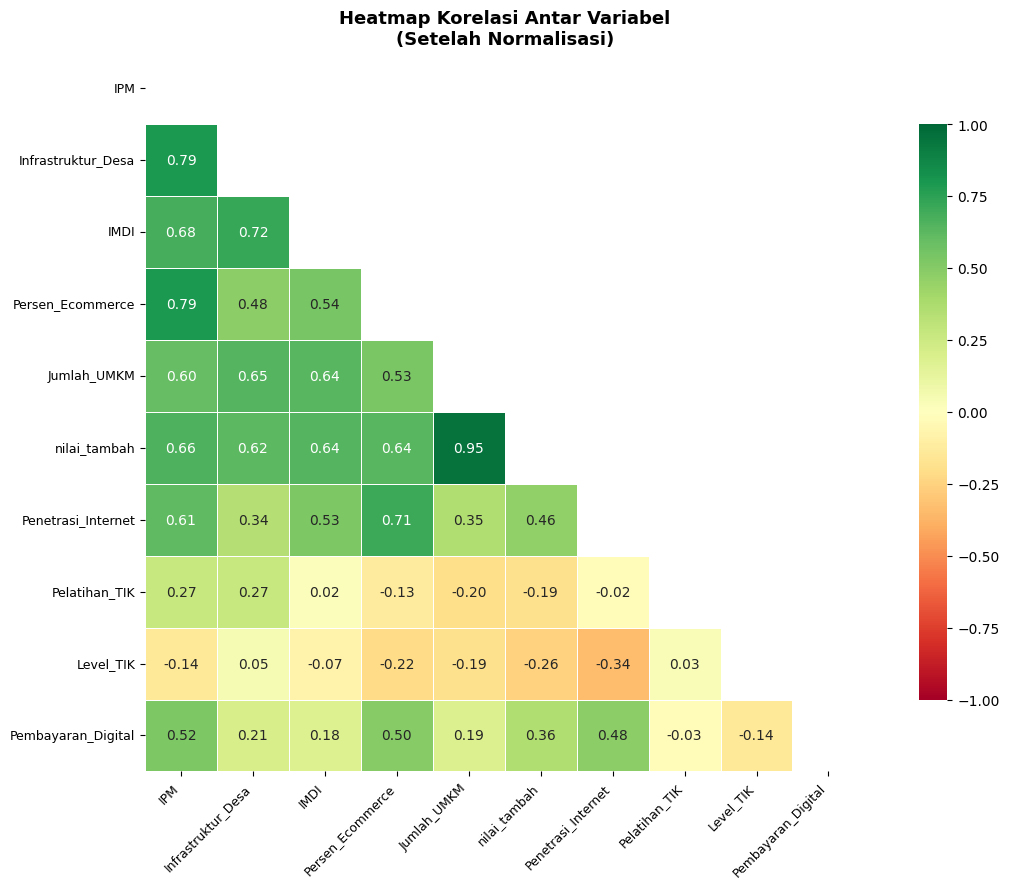


Pasangan variabel dengan korelasi > 0.85:
  Jumlah_UMKM & nilai_tambah: r = 0.952


In [18]:
corr = df_standard.drop(columns=['Provinsi']).corr()

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title('Heatmap Korelasi Antar Variabel\n(Setelah Normalisasi)',
        fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

# Tampilkan pasangan korelasi tinggi
print("\nPasangan variabel dengan korelasi > 0.85:")
high_corr = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        if abs(corr.iloc[i,j]) > 0.85:
            high_corr.append((corr.columns[i], corr.columns[j], round(corr.iloc[i,j], 3)))

if high_corr:
    for h in high_corr:
        print(f"  {h[0]} & {h[1]}: r = {h[2]}")
else:
    print("  Tidak ada ✅")

In [19]:
import hdbscan
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score
from itertools import product

HBDSCAN dan GMM versi tanpa PCA

In [20]:
from itertools import product
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Siapkan data tanpa PCA
X = df_standard.drop(columns=['Provinsi']).values

best_score = -1
best_params = {}
results = []

for min_cluster, min_samp in product(range(2, 8), range(1, 6)):
    hdb_test = hdbscan.HDBSCAN(
        min_cluster_size=min_cluster,
        min_samples=min_samp
    )
    labels = hdb_test.fit_predict(X)
    mask = labels != -1

    n_clusters = len(set(labels[mask]))
    n_noise = list(labels).count(-1)

    if n_clusters > 1 and sum(mask) > n_clusters:
        sil = silhouette_score(X[mask], labels[mask])
        dbi = davies_bouldin_score(X[mask], labels[mask])
        ch  = calinski_harabasz_score(X[mask], labels[mask])

        results.append({
            'min_cluster_size': min_cluster,
            'min_samples'     : min_samp,
            'n_clusters'      : n_clusters,
            'n_noise'         : n_noise,
            'silhouette'      : round(sil, 3),
            'dbi'             : round(dbi, 3),
            'calinski_harabasz': round(ch, 3)
        })

        if sil > best_score:
            best_score = sil
            best_params = {
                'min_cluster_size': min_cluster,
                'min_samples'     : min_samp
            }

df_tuning = pd.DataFrame(results).sort_values('silhouette', ascending=False)
print("Top 10 kombinasi parameter terbaik:")
print(df_tuning.head(10).to_string(index=False))
print(f"\n✅ Parameter terbaik: {best_params}")
print(f"   Silhouette Score     : {best_score:.3f}")

Top 10 kombinasi parameter terbaik:
 min_cluster_size  min_samples  n_clusters  n_noise  silhouette   dbi  calinski_harabasz
                2            1           2        0       0.529 0.630             13.523
                2            4           2       30       0.378 0.799              5.953
                4            2           2       25       0.309 1.136              7.718
                5            2           2       25       0.309 1.136              7.718
                2            3           2       26       0.253 0.939              3.705
                3            2           2       11       0.250 0.882              6.406
                2            2           2       11       0.250 0.882              6.406
                6            1           2       20       0.240 1.500              6.528
                5            1           2       20       0.240 1.500              6.528
                7            1           2       20       0.240 1.500     

EVALUASI HBDSCAN

In [ ]:
# HDBSCAN Final dengan parameter terbaik
hdb_final = hdbscan.HDBSCAN(min_cluster_size=2, min_samples=2)
labels_hdb_final = hdb_final.fit_predict(X)

df_hasil_hdb = df.copy()
df_hasil_hdb['Cluster_HDBSCAN'] = labels_hdb_final

# Evaluasi
mask_hdb = labels_hdb_final != -1
sil_hdb = silhouette_score(X[mask_hdb], labels_hdb_final[mask_hdb])
dbi_hdb = davies_bouldin_score(X[mask_hdb], labels_hdb_final[mask_hdb])
ch_hdb  = calinski_harabasz_score(X[mask_hdb], labels_hdb_final[mask_hdb])

print("=== HDBSCAN Final ===")
print(f"Jumlah klaster : {len(set(labels_hdb_final)) - (1 if -1 in labels_hdb_final else 0)}")
print(f"Noise points   : {list(labels_hdb_final).count(-1)}")
print(f"Distribusi     :\n{pd.Series(labels_hdb_final).value_counts().sort_index()}")
print(f"\nSilhouette Score      : {sil_hdb:.4f}")
print(f"Davies-Bouldin Index  : {dbi_hdb:.4f}")
print(f"Calinski-Harabasz     : {ch_hdb:.4f}")

# Cek isi tiap klaster
print("=== Isi Klaster HDBSCAN ===")
for cluster in sorted(df_hasil_hdb['Cluster_HDBSCAN'].unique()):
    provinsi_list = df_hasil_hdb[df_hasil_hdb['Cluster_HDBSCAN'] == cluster]['Provinsi'].tolist()
    label = "NOISE" if cluster == -1 else f"Klaster {cluster}"
    print(f"\n{label} ({len(provinsi_list)} provinsi):")
    for p in provinsi_list:
        print(f"  - {p}")

=== HDBSCAN Final ===
Jumlah klaster : 2
Noise points   : 11
Distribusi     :
-1    11
 0     3
 1    24
Name: count, dtype: int64

Silhouette Score      : 0.2502
Davies-Bouldin Index  : 0.8816
Calinski-Harabasz     : 6.4064
=== Isi Klaster HDBSCAN ===

NOISE (11 provinsi):
  - DKI Jakarta
  - D.I. Yogyakarta
  - Banten
  - Nusa Tenggara Timur
  - Kalimantan Timur
  - Sulawesi Barat
  - Papua Barat
  - Papua
  - Papua Selatan
  - Papua Tengah
  - Papua Pegunungan

Klaster 0 (3 provinsi):
  - Jawa Barat
  - Jawa Tengah
  - Jawa Timur

Klaster 1 (24 provinsi):
  - Aceh
  - Sumatera Utara
  - Sumatera Barat
  - Riau
  - Jambi
  - Sumatera Selatan
  - Bengkulu
  - Lampung
  - Kep. Bangka Belitung
  - Kepulauan Riau
  - Bali
  - Nusa Tenggara Barat
  - Kalimantan Barat
  - Kalimantan Tengah
  - Kalimantan Selatan
  - Kalimantan Utara
  - Sulawesi Utara
  - Sulawesi Tengah
  - Sulawesi Selatan
  - Sulawesi Tenggara
  - Gorontalo
  - Maluku
  - Maluku Utara
  - Papua Barat Daya


karena tidak menggunakan PCA, visualisasi menggunakan T-SNE

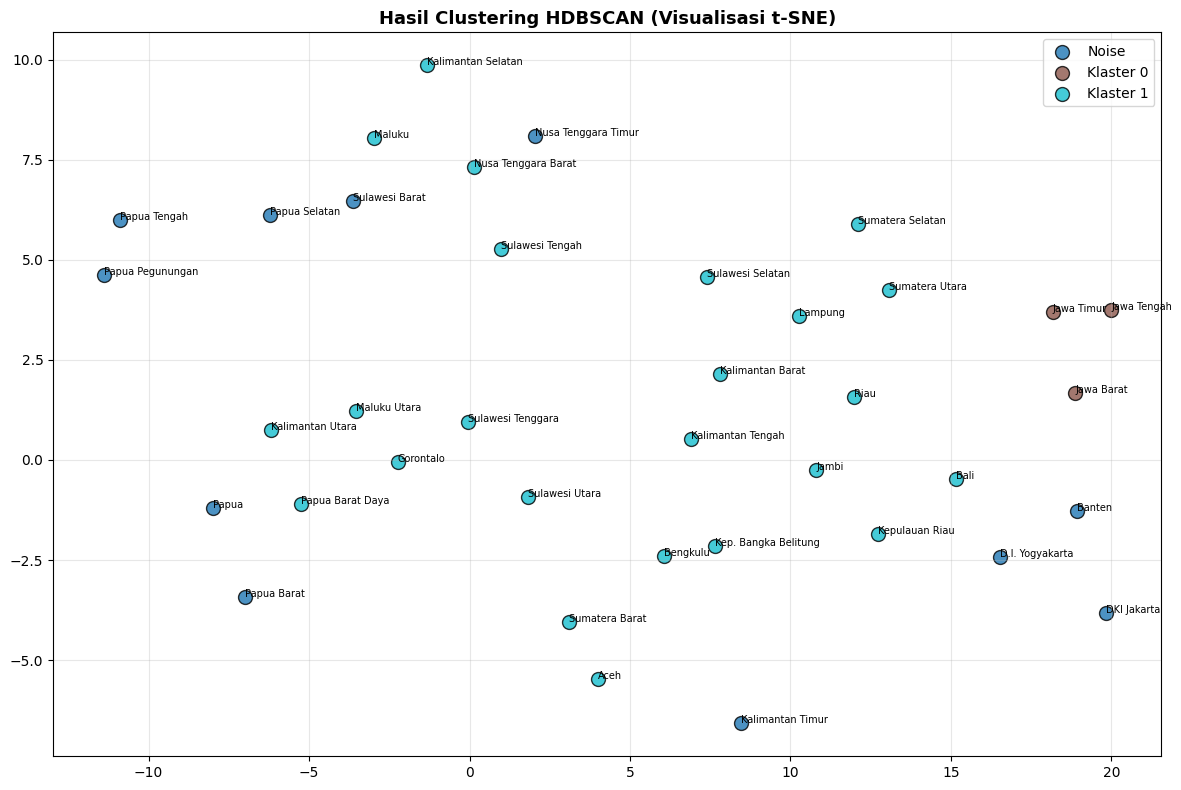

In [22]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42, perplexity=10)
X_tsne = tsne.fit_transform(X)

# Warna per klaster
unique_labels = sorted(set(labels_hdb_final))
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))
color_map = {label: colors[i] for i, label in enumerate(unique_labels)}

plt.figure(figsize=(12, 8))
for label in unique_labels:
    mask = labels_hdb_final == label
    nama = "Noise" if label == -1 else f"Klaster {label}"
    plt.scatter(
        X_tsne[mask, 0], X_tsne[mask, 1],
        c=[color_map[label]], s=100, alpha=0.8,
        edgecolors='black', label=nama
    )

for i, prov in enumerate(df['Provinsi'].values):
    plt.annotate(prov, (X_tsne[i, 0], X_tsne[i, 1]), fontsize=7)

plt.title('Hasil Clustering HDBSCAN (Visualisasi t-SNE)',
          fontsize=13, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

nah dari sini didapat, kalau tanpa PCA justru hasil clustering kurang tajam dimana

noise : papua tengah, papua pegunungab
klaster 0 : jawa timur, jawa tengah, jawa barat
klaster 1 : 34 provinsi sisanya (terlalu lebar)

GMM TANPA PCA

In [23]:
from sklearn.mixture import GaussianMixture

# Tuning GMM - coba berbagai jumlah komponen
results_gmm = []

for n_comp in range(2, 8):
    gmm_test = GaussianMixture(n_components=n_comp, random_state=42, n_init=10)
    labels_gmm_test = gmm_test.fit_predict(X)
    
    sil = silhouette_score(X, labels_gmm_test)
    dbi = davies_bouldin_score(X, labels_gmm_test)
    ch  = calinski_harabasz_score(X, labels_gmm_test)
    bic = gmm_test.bic(X)
    aic = gmm_test.aic(X)
    
    results_gmm.append({
        'n_components' : n_comp,
        'silhouette'   : round(sil, 3),
        'dbi'          : round(dbi, 3),
        'calinski_harabasz': round(ch, 3),
        'BIC'          : round(bic, 3),
        'AIC'          : round(aic, 3)
    })

df_tuning_gmm = pd.DataFrame(results_gmm)
print("Hasil Tuning GMM:")
print(df_tuning_gmm.to_string(index=False))

# Parameter terbaik berdasarkan silhouette
best_gmm = df_tuning_gmm.loc[df_tuning_gmm['silhouette'].idxmax()]
print(f"\n✅ Parameter terbaik: n_components = {int(best_gmm['n_components'])}")
print(f"   Silhouette Score     : {best_gmm['silhouette']:.3f}")
print(f"   Davies-Bouldin Index : {best_gmm['dbi']:.3f}")
print(f"   Calinski-Harabasz    : {best_gmm['calinski_harabasz']:.3f}")

Hasil Tuning GMM:
 n_components  silhouette   dbi  calinski_harabasz     BIC      AIC
            2       0.529 0.630             13.523 862.630  648.106
            3       0.209 1.317             13.008 560.472  237.868
            4       0.136 1.529             10.334 583.612  152.927
            5       0.204 1.267             14.302 485.554  -53.212
            6       0.166 1.250             13.152 110.666 -536.181
            7       0.182 1.198             13.336  58.990 -695.938

✅ Parameter terbaik: n_components = 2
   Silhouette Score     : 0.529
   Davies-Bouldin Index : 0.630
   Calinski-Harabasz    : 13.523


EVALUASI GMM

In [24]:
from sklearn.mixture import GaussianMixture

# Tuning GMM
results_gmm = []

for n_comp in range(2, 8):
    gmm_test = GaussianMixture(n_components=n_comp, random_state=42, n_init=10)
    labels_gmm_test = gmm_test.fit_predict(X)
    
    sil = silhouette_score(X, labels_gmm_test)
    dbi = davies_bouldin_score(X, labels_gmm_test)
    ch  = calinski_harabasz_score(X, labels_gmm_test)
    bic = gmm_test.bic(X)
    aic = gmm_test.aic(X)
    
    results_gmm.append({
        'n_components'     : n_comp,
        'silhouette'       : round(sil, 3),
        'dbi'              : round(dbi, 3),
        'calinski_harabasz': round(ch, 3),
        'BIC'              : round(bic, 3),
        'AIC'              : round(aic, 3)
    })

df_tuning_gmm = pd.DataFrame(results_gmm)
print("Hasil Tuning GMM:")
print(df_tuning_gmm.to_string(index=False))

best_gmm = df_tuning_gmm.loc[df_tuning_gmm['silhouette'].idxmax()]
print(f"\n✅ Parameter terbaik: n_components = {int(best_gmm['n_components'])}")
print(f"   Silhouette Score     : {best_gmm['silhouette']:.3f}")
print(f"   Davies-Bouldin Index : {best_gmm['dbi']:.3f}")
print(f"   Calinski-Harabasz    : {best_gmm['calinski_harabasz']:.3f}")
print(f"   BIC                  : {best_gmm['BIC']:.3f}")
print(f"   AIC                  : {best_gmm['AIC']:.3f}")

Hasil Tuning GMM:
 n_components  silhouette   dbi  calinski_harabasz     BIC      AIC
            2       0.529 0.630             13.523 862.630  648.106
            3       0.209 1.317             13.008 560.472  237.868
            4       0.136 1.529             10.334 583.612  152.927
            5       0.204 1.267             14.302 485.554  -53.212
            6       0.166 1.250             13.152 110.666 -536.181
            7       0.182 1.198             13.336  58.990 -695.938

✅ Parameter terbaik: n_components = 2
   Silhouette Score     : 0.529
   Davies-Bouldin Index : 0.630
   Calinski-Harabasz    : 13.523
   BIC                  : 862.630
   AIC                  : 648.106


In [25]:
# GMM Final dengan parameter terbaik
gmm_final = GaussianMixture(n_components=2, random_state=42, n_init=10)
labels_gmm_final = gmm_final.fit_predict(X)

# Tambahkan label ke dataframe
df_hasil_gmm = df.copy()
df_hasil_gmm['Cluster_GMM'] = labels_gmm_final

# Evaluasi
sil_gmm = silhouette_score(X, labels_gmm_final)
dbi_gmm = davies_bouldin_score(X, labels_gmm_final)
ch_gmm  = calinski_harabasz_score(X, labels_gmm_final)

print("=== GMM Final ===")
print(f"Jumlah klaster : {len(set(labels_gmm_final))}")
print(f"Distribusi     :\n{pd.Series(labels_gmm_final).value_counts().sort_index()}")
print(f"\nSilhouette Score      : {sil_gmm:.4f}")
print(f"Davies-Bouldin Index  : {dbi_gmm:.4f}")
print(f"Calinski-Harabasz     : {ch_gmm:.4f}")

# Isi tiap klaster
print("\n=== Isi Klaster GMM ===")
for cluster in sorted(df_hasil_gmm['Cluster_GMM'].unique()):
    provinsi_list = df_hasil_gmm[df_hasil_gmm['Cluster_GMM'] == cluster]['Provinsi'].tolist()
    print(f"\nKlaster {cluster} ({len(provinsi_list)} provinsi):")
    for p in provinsi_list:
        print(f"  - {p}")

=== GMM Final ===
Jumlah klaster : 2
Distribusi     :
0    36
1     2
Name: count, dtype: int64

Silhouette Score      : 0.5294
Davies-Bouldin Index  : 0.6301
Calinski-Harabasz     : 13.5230

=== Isi Klaster GMM ===

Klaster 0 (36 provinsi):
  - Aceh
  - Sumatera Utara
  - Sumatera Barat
  - Riau
  - Jambi
  - Sumatera Selatan
  - Bengkulu
  - Lampung
  - Kep. Bangka Belitung
  - Kepulauan Riau
  - DKI Jakarta
  - Jawa Barat
  - Jawa Tengah
  - D.I. Yogyakarta
  - Jawa Timur
  - Banten
  - Bali
  - Nusa Tenggara Barat
  - Nusa Tenggara Timur
  - Kalimantan Barat
  - Kalimantan Tengah
  - Kalimantan Selatan
  - Kalimantan Timur
  - Kalimantan Utara
  - Sulawesi Utara
  - Sulawesi Tengah
  - Sulawesi Selatan
  - Sulawesi Tenggara
  - Gorontalo
  - Sulawesi Barat
  - Maluku
  - Maluku Utara
  - Papua Barat
  - Papua Barat Daya
  - Papua
  - Papua Selatan

Klaster 1 (2 provinsi):
  - Papua Tengah
  - Papua Pegunungan


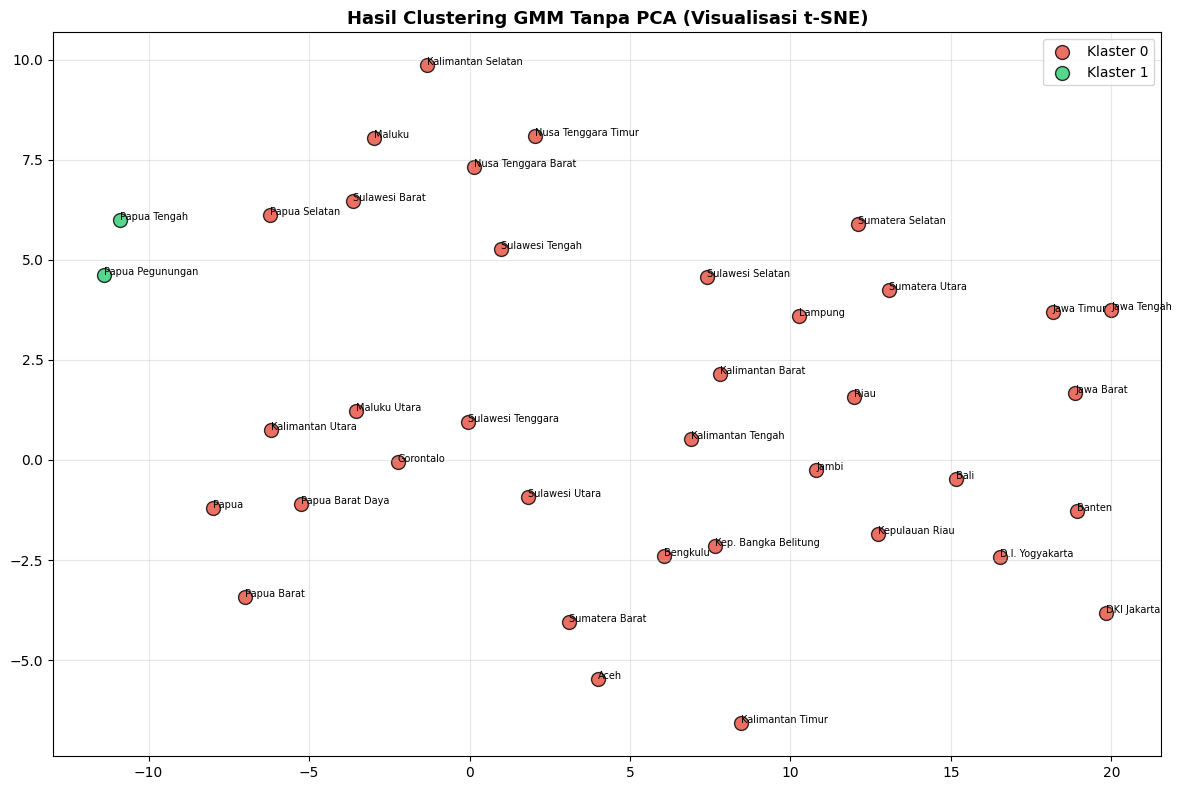

In [37]:

from sklearn.manifold import TSNE

tsne_gmm = TSNE(n_components=2, random_state=42, perplexity=10)
X_tsne_gmm = tsne_gmm.fit_transform(X)

unique_labels_gmm = sorted(set(labels_gmm_final))

palette = ['#E74C3C', '#2ECC71', '#3498DB', '#F39C12', '#9B59B6']
color_map_gmm = {label: palette[i] for i, label in enumerate(unique_labels_gmm)}

plt.figure(figsize=(12, 8))
for label in unique_labels_gmm:
    mask = labels_gmm_final == label
    plt.scatter(
        X_tsne_gmm[mask, 0], X_tsne_gmm[mask, 1],
        c=color_map_gmm[label], s=100, alpha=0.8,
        edgecolors='black', label=f'Klaster {label}'
    )

for i, prov in enumerate(df['Provinsi'].values):
    plt.annotate(prov, (X_tsne_gmm[i, 0], X_tsne_gmm[i, 1]), fontsize=7)

plt.title('Hasil Clustering GMM Tanpa PCA (Visualisasi t-SNE)',
          fontsize=13, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

versi pake PCA

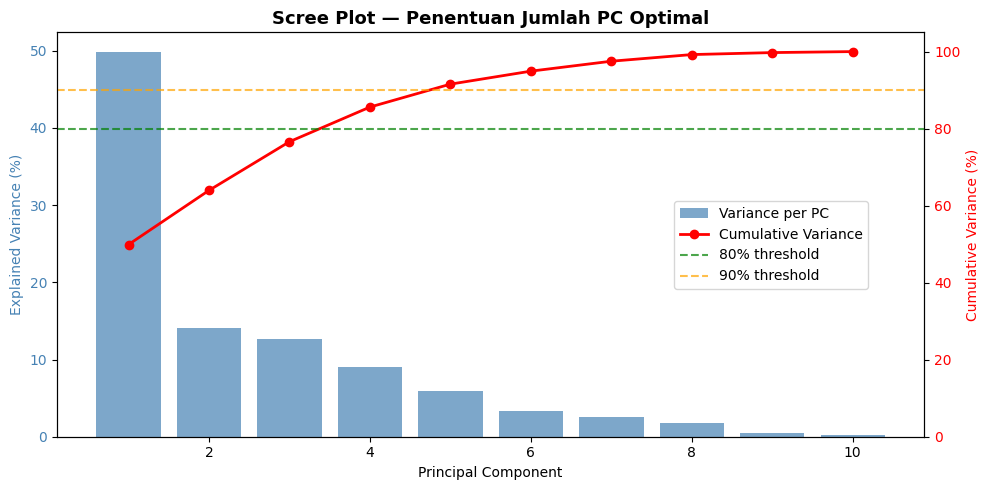


Variance Explained per PC:
PC      Variance (%)  Cumulative (%)
------------------------------------
PC1            49.90           49.90
PC2            14.06           63.96
PC3            12.64           76.60
PC4             9.00           85.60
PC5             5.95           91.55
PC6             3.37           94.92
PC7             2.58           97.50
PC8             1.72           99.23
PC9             0.52           99.74
PC10            0.26          100.00


In [27]:
from sklearn.decomposition import PCA

# Fit PCA dengan semua komponen dulu
pca_full = PCA()
pca_full.fit(X)

# Hitung variance explained
explained_var = pca_full.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

# Plot
fig, ax1 = plt.subplots(figsize=(10, 5))

# Bar chart variance per PC
ax1.bar(range(1, len(explained_var)+1), explained_var * 100,
        color='steelblue', alpha=0.7, label='Variance per PC')
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Explained Variance (%)', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

# Line chart cumulative variance
ax2 = ax1.twinx()
ax2.plot(range(1, len(cumulative_var)+1), cumulative_var * 100,
        'ro-', linewidth=2, markersize=6, label='Cumulative Variance')
ax2.axhline(y=80, color='green', linestyle='--', alpha=0.7, label='80% threshold')
ax2.axhline(y=90, color='orange', linestyle='--', alpha=0.7, label='90% threshold')
ax2.set_ylabel('Cumulative Variance (%)', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(0, 105)

plt.title('Scree Plot — Penentuan Jumlah PC Optimal', fontsize=13, fontweight='bold')
fig.legend(loc='center right', bbox_to_anchor=(0.88, 0.5))
plt.tight_layout()
plt.show()

print("\nVariance Explained per PC:")
print(f"{'PC':<6} {'Variance (%)':>13} {'Cumulative (%)':>15}")
print("-" * 36)
for i, (var, cum) in enumerate(zip(explained_var * 100, cumulative_var * 100)):
        print(f"PC{i+1:<4} {var:>13.2f} {cum:>15.2f}")



Factor Loadings (Varimax Rotation):
                      PC1    PC2    PC3    PC4
IPM                 0.691  0.334  0.607 -0.030
Infrastruktur_Desa  0.844  0.370  0.181  0.162
IMDI                0.829  0.115  0.221 -0.009
Persen_Ecommerce    0.533 -0.092  0.712 -0.139
Jumlah_UMKM         0.927 -0.228  0.074 -0.145
nilai_tambah        0.874 -0.230  0.258 -0.193
Penetrasi_Internet  0.337  0.039  0.721 -0.340
Pelatihan_TIK      -0.038  0.980 -0.019  0.002
Level_TIK          -0.059  0.009 -0.101  0.987
Pembayaran_Digital  0.045 -0.048  0.890  0.003

Shape setelah PCA Varimax: (38, 4)


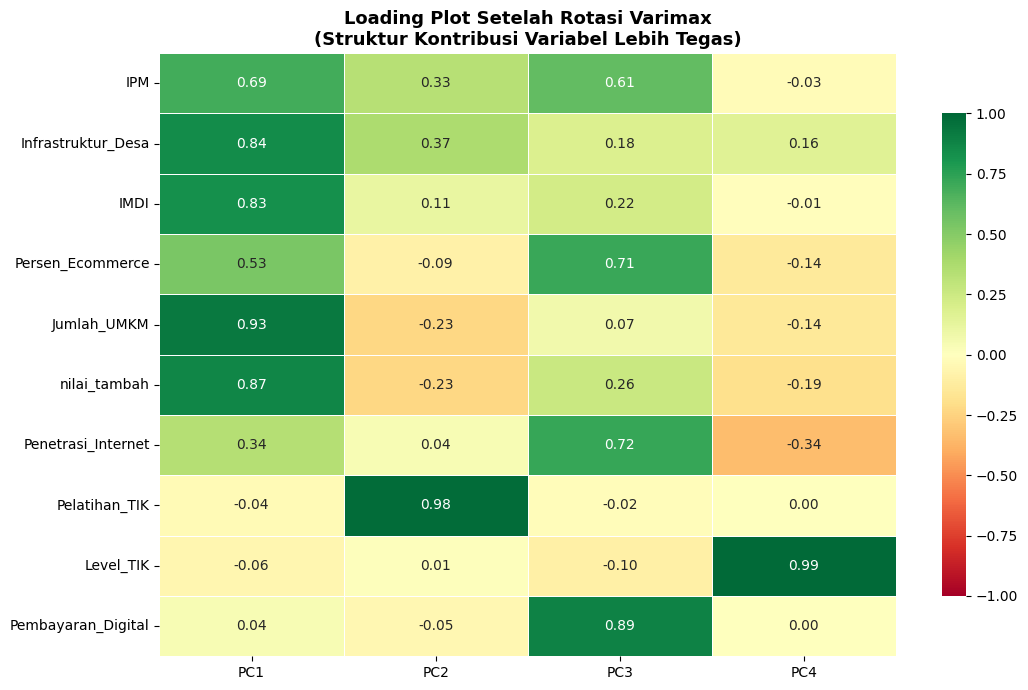

In [28]:
from sklearn.decomposition import PCA
from scipy.stats import ortho_group
import numpy as np

n_components = np.argmax(np.cumsum(pca_full.explained_variance_ratio_) >= 0.80) + 1

# PCA dulu
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X)

# Fungsi Varimax rotation manual
def varimax(Phi, gamma=1.0, q=20, tol=1e-6):
    p, k = Phi.shape
    R = np.eye(k)
    d = 0
    for _ in range(q):
        d_old = d
        Lambda = Phi @ R
        u, s, vh = np.linalg.svd(
            Phi.T @ (Lambda**3 - (gamma/p) * Lambda @ np.diag(np.diag(Lambda.T @ Lambda)))
        )
        R = u @ vh
        d = np.sum(s)
        if d_old != 0 and d/d_old < 1 + tol:
            break
    return Phi @ R, R

# Terapkan Varimax ke loadings PCA
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
loadings_varimax, rotation_matrix = varimax(loadings)

loadings_df = pd.DataFrame(
    loadings_varimax,
    index=df_standard.drop(columns=['Provinsi']).columns,
    columns=[f'PC{i+1}' for i in range(n_components)]
)

print("Factor Loadings (Varimax Rotation):")
print(loadings_df.round(3))

# Transform data
# Transform data - cara yang benar
X_pca = X_pca  # sudah dari pca.fit_transform(X) di atas, tinggal rotate
X_pca_varimax = (X_pca @ rotation_matrix)

print(f"\nShape setelah PCA Varimax: {X_pca_varimax.shape}")

plt.figure(figsize=(11, 7))
sns.heatmap(loadings_df, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1, 
            linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Loading Plot Setelah Rotasi Varimax\n(Struktur Kontribusi Variabel Lebih Tegas)', 
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

START HDBSCAN


In [29]:
# HDBSCAN tuning dengan PCA Varimax
best_score = -1
best_params = {}
results_pca = []

for min_cluster, min_samp in product(range(2, 8), range(1, 6)):
    hdb_test = hdbscan.HDBSCAN(
        min_cluster_size=min_cluster,
        min_samples=min_samp
    )
    labels = hdb_test.fit_predict(X_pca_varimax)
    mask = labels != -1

    n_clusters = len(set(labels[mask]))
    n_noise = list(labels).count(-1)

    if n_clusters > 1 and sum(mask) > n_clusters:
        sil = silhouette_score(X_pca_varimax[mask], labels[mask])
        dbi = davies_bouldin_score(X_pca_varimax[mask], labels[mask])
        ch  = calinski_harabasz_score(X_pca_varimax[mask], labels[mask])

        results_pca.append({
            'min_cluster_size' : min_cluster,
            'min_samples'      : min_samp,
            'n_clusters'       : n_clusters,
            'n_noise'          : n_noise,
            'silhouette'       : round(sil, 3),
            'dbi'              : round(dbi, 3),
            'calinski_harabasz': round(ch, 3)
        })

        if sil > best_score:
            best_score = sil
            best_params = {
                'min_cluster_size': min_cluster,
                'min_samples'     : min_samp
            }

df_tuning_pca = pd.DataFrame(results_pca).sort_values('silhouette', ascending=False)
print("Top 10 kombinasi parameter terbaik (PCA Varimax):")
print(df_tuning_pca.head(10).to_string(index=False))
print(f"\nParameter terbaik: {best_params}")
print(f"   Silhouette Score : {best_score:.3f}")

Top 10 kombinasi parameter terbaik (PCA Varimax):
 min_cluster_size  min_samples  n_clusters  n_noise  silhouette   dbi  calinski_harabasz
                2            1           2        0       0.579 0.556             16.644
                2            5           2       31       0.417 0.741              7.030
                4            2           2       27       0.396 0.828              9.047
                4            4           2       26       0.387 0.838             10.258
                3            4           2       26       0.387 0.838             10.258
                6            3           2       21       0.373 0.932             15.272
                5            3           2       21       0.373 0.932             15.272
                4            3           2       21       0.373 0.932             15.272
                3            3           2       21       0.373 0.932             15.272
                7            3           2       21       0.

In [30]:
# HDBSCAN Final dengan PCA Varimax
hdb_pca_final = hdbscan.HDBSCAN(min_cluster_size=2, min_samples=1)
labels_hdb_pca = hdb_pca_final.fit_predict(X_pca_varimax)

df_hasil_hdb_pca = df.copy()
df_hasil_hdb_pca['Cluster_HDBSCAN'] = labels_hdb_pca

# Evaluasi — exclude noise (-1)
mask_hdb_pca = labels_hdb_pca != -1

if len(set(labels_hdb_pca[mask_hdb_pca])) > 1:
    sil = silhouette_score(X_pca_varimax[mask_hdb_pca], labels_hdb_pca[mask_hdb_pca])
    dbi = davies_bouldin_score(X_pca_varimax[mask_hdb_pca], labels_hdb_pca[mask_hdb_pca])
    ch  = calinski_harabasz_score(X_pca_varimax[mask_hdb_pca], labels_hdb_pca[mask_hdb_pca])
else:
    print("Tidak cukup cluster untuk evaluasi")

print("=== HDBSCAN Final (PCA Varimax) ===")
print(f"Jumlah klaster : {len(set(labels_hdb_pca)) - (1 if -1 in labels_hdb_pca else 0)}")
print(f"Noise points   : {list(labels_hdb_pca).count(-1)}")
print(f"Distribusi     :\n{pd.Series(labels_hdb_pca).value_counts().sort_index()}")
print(f"\nSilhouette Score     : {sil:.4f}")
print(f"Davies-Bouldin Index : {dbi:.4f}")
print(f"Calinski-Harabasz    : {ch:.4f}")

# Isi klaster
print("\n=== Isi Klaster ===")
for cluster in sorted(df_hasil_hdb_pca['Cluster_HDBSCAN'].unique()):
    prov_list = df_hasil_hdb_pca[df_hasil_hdb_pca['Cluster_HDBSCAN'] == cluster]['Provinsi'].tolist()
    label = "NOISE" if cluster == -1 else f"Klaster {cluster}"
    print(f"\n{label} ({len(prov_list)} provinsi):")
    for p in prov_list:
        print(f"  - {p}")

=== HDBSCAN Final (PCA Varimax) ===
Jumlah klaster : 2
Noise points   : 0
Distribusi     :
0     2
1    36
Name: count, dtype: int64

Silhouette Score     : 0.5789
Davies-Bouldin Index : 0.5564
Calinski-Harabasz    : 16.6442

=== Isi Klaster ===

Klaster 0 (2 provinsi):
  - Papua Tengah
  - Papua Pegunungan

Klaster 1 (36 provinsi):
  - Aceh
  - Sumatera Utara
  - Sumatera Barat
  - Riau
  - Jambi
  - Sumatera Selatan
  - Bengkulu
  - Lampung
  - Kep. Bangka Belitung
  - Kepulauan Riau
  - DKI Jakarta
  - Jawa Barat
  - Jawa Tengah
  - D.I. Yogyakarta
  - Jawa Timur
  - Banten
  - Bali
  - Nusa Tenggara Barat
  - Nusa Tenggara Timur
  - Kalimantan Barat
  - Kalimantan Tengah
  - Kalimantan Selatan
  - Kalimantan Timur
  - Kalimantan Utara
  - Sulawesi Utara
  - Sulawesi Tengah
  - Sulawesi Selatan
  - Sulawesi Tenggara
  - Gorontalo
  - Sulawesi Barat
  - Maluku
  - Maluku Utara
  - Papua Barat
  - Papua Barat Daya
  - Papua
  - Papua Selatan


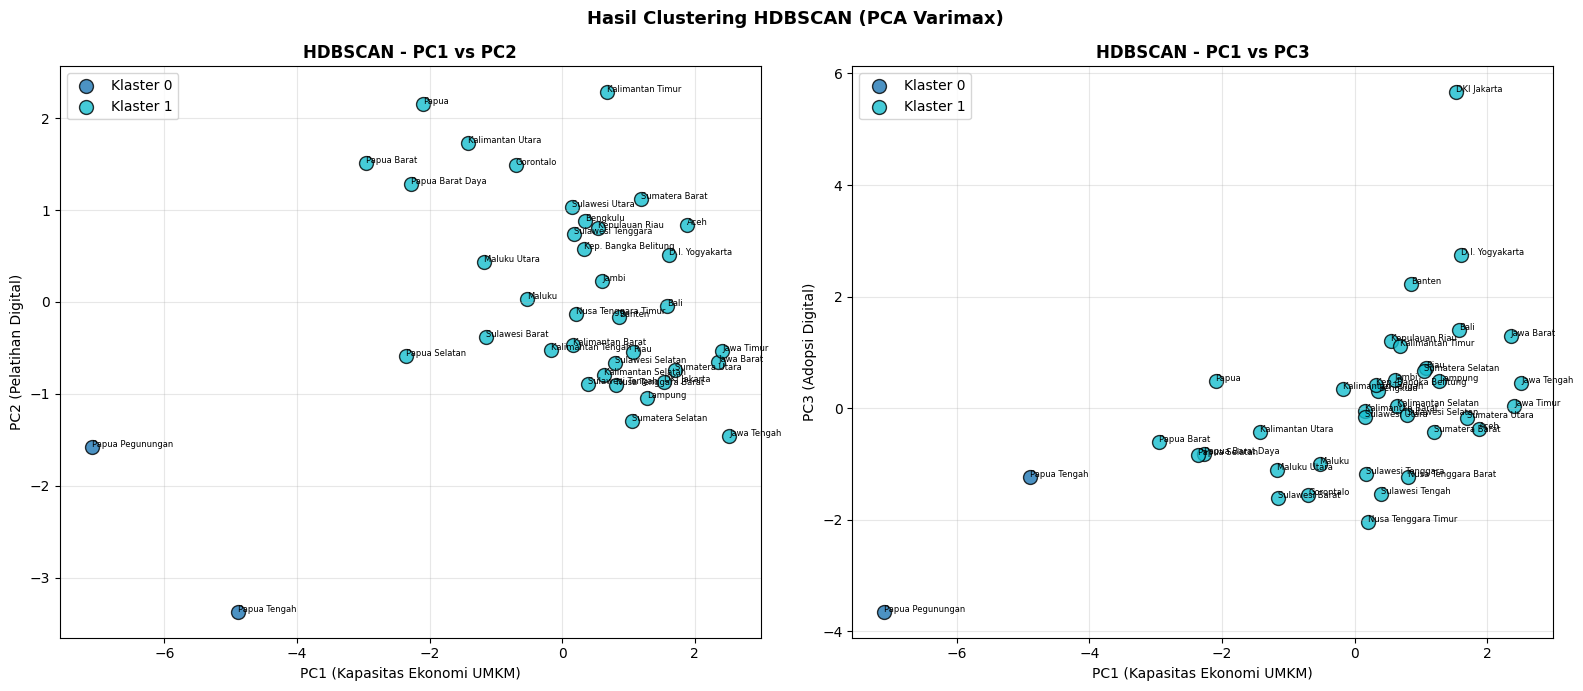

In [31]:
# Visualisasi HDBSCAN PCA Varimax
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Plot 1: PC1 vs PC2
unique_labels = sorted(set(labels_hdb_pca))
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))
color_map = {label: colors[i] for i, label in enumerate(unique_labels)}

for label in unique_labels:
    mask = labels_hdb_pca == label
    nama = "Noise" if label == -1 else f"Klaster {label}"
    axes[0].scatter(
        X_pca_varimax[mask, 0], X_pca_varimax[mask, 1],
        c=[color_map[label]], s=100, alpha=0.8,
        edgecolors='black', label=nama
    )
for i, prov in enumerate(df['Provinsi'].values):
    axes[0].annotate(prov, (X_pca_varimax[i, 0], X_pca_varimax[i, 1]), fontsize=6)

axes[0].set_xlabel('PC1 (Kapasitas Ekonomi UMKM)')
axes[0].set_ylabel('PC2 (Pelatihan Digital)')
axes[0].set_title('HDBSCAN - PC1 vs PC2', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot 2: PC1 vs PC3
for label in unique_labels:
    mask = labels_hdb_pca == label
    nama = "Noise" if label == -1 else f"Klaster {label}"
    axes[1].scatter(
        X_pca_varimax[mask, 0], X_pca_varimax[mask, 2],
        c=[color_map[label]], s=100, alpha=0.8,
        edgecolors='black', label=nama
    )
for i, prov in enumerate(df['Provinsi'].values):
    axes[1].annotate(prov, (X_pca_varimax[i, 0], X_pca_varimax[i, 2]), fontsize=6)

axes[1].set_xlabel('PC1 (Kapasitas Ekonomi UMKM)')
axes[1].set_ylabel('PC3 (Adopsi Digital)')
axes[1].set_title('HDBSCAN - PC1 vs PC3', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Hasil Clustering HDBSCAN (PCA Varimax)', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [32]:
# GMM tuning dengan PCA Varimax
results_gmm_pca = []

for n_comp in range(2, 8):
    gmm_test = GaussianMixture(n_components=n_comp, random_state=42, n_init=10)
    labels_gmm_test = gmm_test.fit_predict(X_pca_varimax)
    
    sil = silhouette_score(X_pca_varimax, labels_gmm_test)
    dbi = davies_bouldin_score(X_pca_varimax, labels_gmm_test)
    ch  = calinski_harabasz_score(X_pca_varimax, labels_gmm_test)
    bic = gmm_test.bic(X_pca_varimax)
    aic = gmm_test.aic(X_pca_varimax)
    
    results_gmm_pca.append({
        'n_components'     : n_comp,
        'silhouette'       : round(sil, 3),
        'dbi'              : round(dbi, 3),
        'calinski_harabasz': round(ch, 3),
        'BIC'              : round(bic, 3),
        'AIC'              : round(aic, 3)
    })

df_tuning_gmm_pca = pd.DataFrame(results_gmm_pca)
print("Hasil Tuning GMM (PCA Varimax):")
print(df_tuning_gmm_pca.to_string(index=False))

best_gmm_pca = df_tuning_gmm_pca.loc[df_tuning_gmm_pca['silhouette'].idxmax()]
print(f"\nParameter terbaik: n_components = {int(best_gmm_pca['n_components'])}")
print(f"   Silhouette Score     : {best_gmm_pca['silhouette']:.3f}")
print(f"   Davies-Bouldin Index : {best_gmm_pca['dbi']:.3f}")
print(f"   Calinski-Harabasz    : {best_gmm_pca['calinski_harabasz']:.3f}")

Hasil Tuning GMM (PCA Varimax):
 n_components  silhouette   dbi  calinski_harabasz     BIC     AIC
            2       0.579 0.556             16.644 483.781 436.291
            3       0.289 1.016             20.929 495.570 423.516
            4       0.282 0.816             18.877 476.350 379.732
            5       0.252 1.097             19.130 479.813 358.631
            6       0.245 0.798             18.451 470.620 324.875
            7       0.218 1.023             15.701 454.321 284.012

Parameter terbaik: n_components = 2
   Silhouette Score     : 0.579
   Davies-Bouldin Index : 0.556
   Calinski-Harabasz    : 16.644


=== Isi Klaster GMM (PCA Varimax) ===

Klaster 0 (36 provinsi):
  - Aceh
  - Sumatera Utara
  - Sumatera Barat
  - Riau
  - Jambi
  - Sumatera Selatan
  - Bengkulu
  - Lampung
  - Kep. Bangka Belitung
  - Kepulauan Riau
  - DKI Jakarta
  - Jawa Barat
  - Jawa Tengah
  - D.I. Yogyakarta
  - Jawa Timur
  - Banten
  - Bali
  - Nusa Tenggara Barat
  - Nusa Tenggara Timur
  - Kalimantan Barat
  - Kalimantan Tengah
  - Kalimantan Selatan
  - Kalimantan Timur
  - Kalimantan Utara
  - Sulawesi Utara
  - Sulawesi Tengah
  - Sulawesi Selatan
  - Sulawesi Tenggara
  - Gorontalo
  - Sulawesi Barat
  - Maluku
  - Maluku Utara
  - Papua Barat
  - Papua Barat Daya
  - Papua
  - Papua Selatan

Klaster 1 (2 provinsi):
  - Papua Tengah
  - Papua Pegunungan


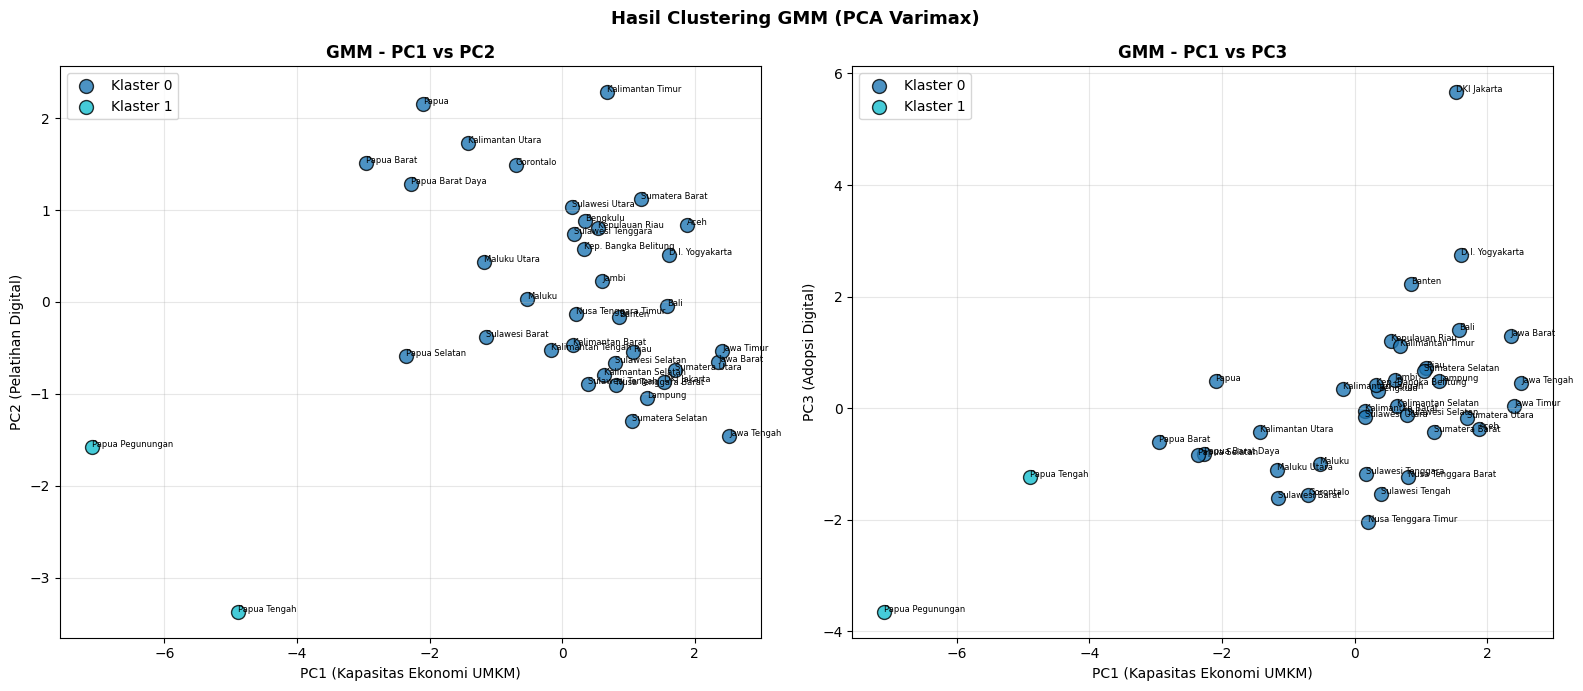

Silhouette Score     : 0.5789
Davies-Bouldin Index : 0.5564
Calinski-Harabasz    : 16.6442


In [33]:
# GMM Final dengan PCA Varimax
gmm_pca_final = GaussianMixture(n_components=2, random_state=42, n_init=10)
labels_gmm_pca = gmm_pca_final.fit_predict(X_pca_varimax)

df_hasil_gmm_pca = df.copy()
df_hasil_gmm_pca['Cluster_GMM'] = labels_gmm_pca

# Isi klaster
print("=== Isi Klaster GMM (PCA Varimax) ===")
for cluster in sorted(df_hasil_gmm_pca['Cluster_GMM'].unique()):
    prov_list = df_hasil_gmm_pca[df_hasil_gmm_pca['Cluster_GMM'] == cluster]['Provinsi'].tolist()
    print(f"\nKlaster {cluster} ({len(prov_list)} provinsi):")
    for p in prov_list:
        print(f"  - {p}")

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

unique_labels = sorted(set(labels_gmm_pca))
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))
color_map = {label: colors[i] for i, label in enumerate(unique_labels)}

# Plot 1: PC1 vs PC2
for label in unique_labels:
    mask = labels_gmm_pca == label
    axes[0].scatter(
        X_pca_varimax[mask, 0], X_pca_varimax[mask, 1],
        c=[color_map[label]], s=100, alpha=0.8,
        edgecolors='black', label=f'Klaster {label}'
    )
for i, prov in enumerate(df['Provinsi'].values):
    axes[0].annotate(prov, (X_pca_varimax[i, 0], X_pca_varimax[i, 1]), fontsize=6)

axes[0].set_xlabel('PC1 (Kapasitas Ekonomi UMKM)')
axes[0].set_ylabel('PC2 (Pelatihan Digital)')
axes[0].set_title('GMM - PC1 vs PC2', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot 2: PC1 vs PC3
for label in unique_labels:
    mask = labels_gmm_pca == label
    axes[1].scatter(
        X_pca_varimax[mask, 0], X_pca_varimax[mask, 2],
        c=[color_map[label]], s=100, alpha=0.8,
        edgecolors='black', label=f'Klaster {label}'
    )
for i, prov in enumerate(df['Provinsi'].values):
    axes[1].annotate(prov, (X_pca_varimax[i, 0], X_pca_varimax[i, 2]), fontsize=6)

axes[1].set_xlabel('PC1 (Kapasitas Ekonomi UMKM)')
axes[1].set_ylabel('PC3 (Adopsi Digital)')
axes[1].set_title('GMM - PC1 vs PC3', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Hasil Clustering GMM (PCA Varimax)',
            fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Tambahkan ini di cell 40 setelah fit GMM
sil_gmm_pca = silhouette_score(X_pca_varimax, labels_gmm_pca)
dbi_gmm_pca = davies_bouldin_score(X_pca_varimax, labels_gmm_pca)
ch_gmm_pca  = calinski_harabasz_score(X_pca_varimax, labels_gmm_pca)

print(f"Silhouette Score     : {sil_gmm_pca:.4f}")
print(f"Davies-Bouldin Index : {dbi_gmm_pca:.4f}")
print(f"Calinski-Harabasz    : {ch_gmm_pca:.4f}")

In [35]:
# Tabel komparasi semua skenario
komparasi_final = pd.DataFrame([
    {
        'Skenario'    : 'Tanpa PCA',
        'Metode'      : 'HDBSCAN',
        'n_cluster'   : 2,
        'n_noise'     : 11,
        'Silhouette'  : 0.529,
        'DBI'         : 0.630,
        'CH'          : 13.523
    },
    {
        'Skenario'    : 'Tanpa PCA',
        'Metode'      : 'GMM',
        'n_cluster'   : 2,
        'n_noise'     : 0,
        'Silhouette'  : 0.529,
        'DBI'         : 0.630,
        'CH'          : 13.523
    },
    {
        'Skenario'    : 'Dengan PCA Varimax',
        'Metode'      : 'HDBSCAN',
        'n_cluster'   : 2,
        'n_noise'     : 0,
        'Silhouette'  : 0.5789,
        'DBI'         : 0.5564,
        'CH'          : 16.644
    },
    {
        'Skenario'    : 'Dengan PCA Varimax',
        'Metode'      : 'GMM',
        'n_cluster'   : 2,
        'n_noise'     : 0,
        'Silhouette'  : 0.5789,
        'DBI'         : 0.5564,
        'CH'          : 16.644
    },
])

print("=" * 75)
print("TABEL KOMPARASI SEMUA SKENARIO")
print("=" * 75)
print(komparasi_final.to_string(index=False))
print("=" * 75)
print("\nKesimpulan:")
print("Skenario dengan PCA Varimax menghasilkan metrik lebih baik")
print("   (SS lebih tinggi, DBI lebih rendah, CH lebih tinggi)")
print("HDBSCAN dan GMM menghasilkan pengelompokan identik pada PCA Varimax")

TABEL KOMPARASI SEMUA SKENARIO
          Skenario  Metode  n_cluster  n_noise  Silhouette    DBI     CH
         Tanpa PCA HDBSCAN          2       11      0.5290 0.6300 13.523
         Tanpa PCA     GMM          2        0      0.5290 0.6300 13.523
Dengan PCA Varimax HDBSCAN          2        0      0.5789 0.5564 16.644
Dengan PCA Varimax     GMM          2        0      0.5789 0.5564 16.644

Kesimpulan:
Skenario dengan PCA Varimax menghasilkan metrik lebih baik
   (SS lebih tinggi, DBI lebih rendah, CH lebih tinggi)
HDBSCAN dan GMM menghasilkan pengelompokan identik pada PCA Varimax


hasil PCA Varimax kurang maksimal, sehingga kami coba untuk versi pca tanpa varimax

HBDSCAN-TANPA PCA VARIMAX

In [39]:
# HDBSCAN tuning dengan PCA biasa
best_score_pca = -1
best_params_pca = {}
results_pca_biasa = []

for min_cluster, min_samp in product(range(2, 8), range(1, 6)):
    hdb_test = hdbscan.HDBSCAN(
        min_cluster_size=min_cluster,
        min_samples=min_samp
    )
    labels = hdb_test.fit_predict(X_pca)
    mask = labels != -1

    n_clusters = len(set(labels[mask]))
    n_noise = list(labels).count(-1)

    if n_clusters > 1 and sum(mask) > n_clusters:
        sil = silhouette_score(X_pca[mask], labels[mask])
        dbi = davies_bouldin_score(X_pca[mask], labels[mask])
        ch  = calinski_harabasz_score(X_pca[mask], labels[mask])

        results_pca_biasa.append({
            'min_cluster_size' : min_cluster,
            'min_samples'      : min_samp,
            'n_clusters'       : n_clusters,
            'n_noise'          : n_noise,
            'silhouette'       : round(sil, 3),
            'dbi'              : round(dbi, 3),
            'calinski_harabasz': round(ch, 3)
        })

        if sil > best_score_pca:
            best_score_pca = sil
            best_params_pca = {
                'min_cluster_size': min_cluster,
                'min_samples'     : min_samp
            }

df_tuning_pca_biasa = pd.DataFrame(results_pca_biasa).sort_values('silhouette', ascending=False)
print("Top 10 kombinasi parameter terbaik (PCA biasa):")
print(df_tuning_pca_biasa.head(10).to_string(index=False))
print(f"\nParameter terbaik: {best_params_pca}")
print(f"Silhouette Score  : {best_score_pca:.3f}")

Top 10 kombinasi parameter terbaik (PCA biasa):
 min_cluster_size  min_samples  n_clusters  n_noise  silhouette   dbi  calinski_harabasz
                2            1           2        0       0.579 0.556             16.644
                2            5           2       31       0.417 0.741              7.030
                4            2           2       27       0.396 0.828              9.047
                4            4           2       26       0.387 0.838             10.258
                3            4           2       26       0.387 0.838             10.258
                6            3           2       21       0.373 0.932             15.272
                5            3           2       21       0.373 0.932             15.272
                4            3           2       21       0.373 0.932             15.272
                3            3           2       21       0.373 0.932             15.272
                7            3           2       21       0.37

In [40]:
# HDBSCAN Final dengan PCA biasa
hdb_pca_biasa = hdbscan.HDBSCAN(
    min_cluster_size=best_params_pca['min_cluster_size'],
    min_samples=best_params_pca['min_samples']
)
labels_hdb_pca_biasa = hdb_pca_biasa.fit_predict(X_pca)

df_hasil_hdb_pca_biasa = df.copy()
df_hasil_hdb_pca_biasa['Cluster_HDBSCAN'] = labels_hdb_pca_biasa

# Evaluasi — exclude noise
mask_hdb_biasa = labels_hdb_pca_biasa != -1
if len(set(labels_hdb_pca_biasa[mask_hdb_biasa])) > 1:
    sil_hdb_biasa = silhouette_score(X_pca[mask_hdb_biasa], labels_hdb_pca_biasa[mask_hdb_biasa])
    dbi_hdb_biasa = davies_bouldin_score(X_pca[mask_hdb_biasa], labels_hdb_pca_biasa[mask_hdb_biasa])
    ch_hdb_biasa  = calinski_harabasz_score(X_pca[mask_hdb_biasa], labels_hdb_pca_biasa[mask_hdb_biasa])

print("=== HDBSCAN Final (PCA Biasa) ===")
print(f"Jumlah klaster : {len(set(labels_hdb_pca_biasa)) - (1 if -1 in labels_hdb_pca_biasa else 0)}")
print(f"Noise points   : {list(labels_hdb_pca_biasa).count(-1)}")
print(f"Distribusi     :\n{pd.Series(labels_hdb_pca_biasa).value_counts().sort_index()}")
print(f"\nSilhouette Score     : {sil_hdb_biasa:.4f}")
print(f"Davies-Bouldin Index : {dbi_hdb_biasa:.4f}")
print(f"Calinski-Harabasz    : {ch_hdb_biasa:.4f}")

print("\n=== Isi Klaster ===")
for cluster in sorted(df_hasil_hdb_pca_biasa['Cluster_HDBSCAN'].unique()):
    prov_list = df_hasil_hdb_pca_biasa[df_hasil_hdb_pca_biasa['Cluster_HDBSCAN'] == cluster]['Provinsi'].tolist()
    label = "NOISE" if cluster == -1 else f"Klaster {cluster}"
    print(f"\n{label} ({len(prov_list)} provinsi):")
    for p in prov_list:
        print(f"  - {p}")

=== HDBSCAN Final (PCA Biasa) ===
Jumlah klaster : 2
Noise points   : 0
Distribusi     :
0     2
1    36
Name: count, dtype: int64

Silhouette Score     : 0.5789
Davies-Bouldin Index : 0.5564
Calinski-Harabasz    : 16.6442

=== Isi Klaster ===

Klaster 0 (2 provinsi):
  - Papua Tengah
  - Papua Pegunungan

Klaster 1 (36 provinsi):
  - Aceh
  - Sumatera Utara
  - Sumatera Barat
  - Riau
  - Jambi
  - Sumatera Selatan
  - Bengkulu
  - Lampung
  - Kep. Bangka Belitung
  - Kepulauan Riau
  - DKI Jakarta
  - Jawa Barat
  - Jawa Tengah
  - D.I. Yogyakarta
  - Jawa Timur
  - Banten
  - Bali
  - Nusa Tenggara Barat
  - Nusa Tenggara Timur
  - Kalimantan Barat
  - Kalimantan Tengah
  - Kalimantan Selatan
  - Kalimantan Timur
  - Kalimantan Utara
  - Sulawesi Utara
  - Sulawesi Tengah
  - Sulawesi Selatan
  - Sulawesi Tenggara
  - Gorontalo
  - Sulawesi Barat
  - Maluku
  - Maluku Utara
  - Papua Barat
  - Papua Barat Daya
  - Papua
  - Papua Selatan


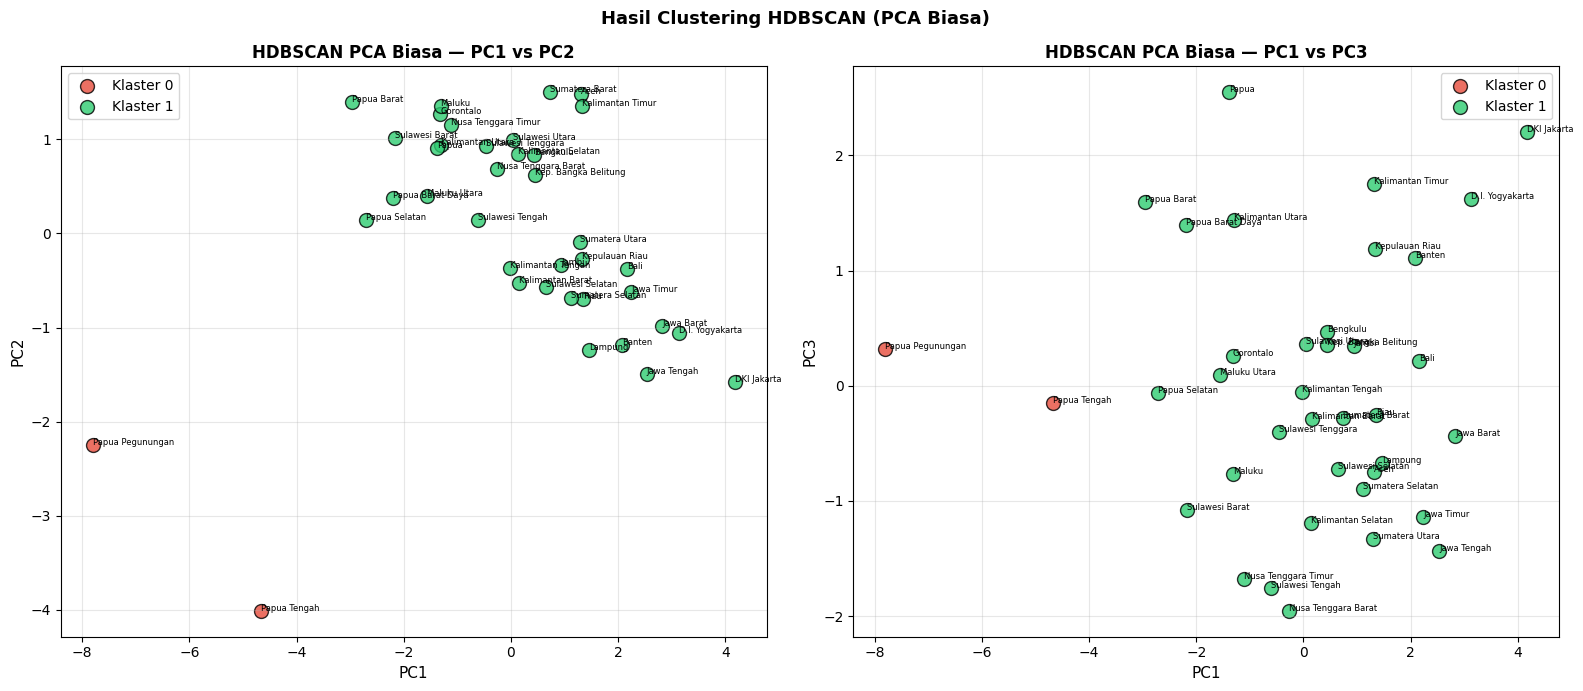

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

unique_labels = sorted(set(labels_hdb_pca_biasa))
palette = ['#E74C3C', '#2ECC71', '#3498DB', '#F39C12', '#9B59B6', '#1ABC9C']
color_map = {label: ('#95A5A6' if label == -1 else palette[i]) 
             for i, label in enumerate(unique_labels)}

# Plot PC1 vs PC2
for label in unique_labels:
    mask = labels_hdb_pca_biasa == label
    nama = "Noise" if label == -1 else f"Klaster {label}"
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=color_map[label], s=100, alpha=0.8,
                    edgecolors='black', label=nama)
for i, prov in enumerate(df['Provinsi'].values):
    axes[0].annotate(prov, (X_pca[i, 0], X_pca[i, 1]), fontsize=6)
axes[0].set_xlabel('PC1', fontsize=11)
axes[0].set_ylabel('PC2', fontsize=11)
axes[0].set_title('HDBSCAN PCA Biasa — PC1 vs PC2', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot PC1 vs PC3
for label in unique_labels:
    mask = labels_hdb_pca_biasa == label
    nama = "Noise" if label == -1 else f"Klaster {label}"
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 2],
                    c=color_map[label], s=100, alpha=0.8,
                    edgecolors='black', label=nama)
for i, prov in enumerate(df['Provinsi'].values):
    axes[1].annotate(prov, (X_pca[i, 0], X_pca[i, 2]), fontsize=6)
axes[1].set_xlabel('PC1', fontsize=11)
axes[1].set_ylabel('PC3', fontsize=11)
axes[1].set_title('HDBSCAN PCA Biasa — PC1 vs PC3', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Hasil Clustering HDBSCAN (PCA Biasa)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

GMM TANPA PCA VARIMAX

In [42]:
# GMM tuning dengan PCA biasa
results_gmm_pca_biasa = []

for n_comp in range(2, 8):
    gmm_test = GaussianMixture(n_components=n_comp, random_state=42, n_init=10)
    labels_test = gmm_test.fit_predict(X_pca)

    sil = silhouette_score(X_pca, labels_test)
    dbi = davies_bouldin_score(X_pca, labels_test)
    ch  = calinski_harabasz_score(X_pca, labels_test)
    bic = gmm_test.bic(X_pca)
    aic = gmm_test.aic(X_pca)

    results_gmm_pca_biasa.append({
        'n_components'     : n_comp,
        'silhouette'       : round(sil, 3),
        'dbi'              : round(dbi, 3),
        'calinski_harabasz': round(ch, 3),
        'BIC'              : round(bic, 3),
        'AIC'              : round(aic, 3)
    })

df_gmm_pca_biasa = pd.DataFrame(results_gmm_pca_biasa)
print("Hasil Tuning GMM (PCA Biasa):")
print(df_gmm_pca_biasa.to_string(index=False))

n_opt_biasa = df_gmm_pca_biasa.loc[df_gmm_pca_biasa['BIC'].idxmin(), 'n_components']
print(f"\nBIC terendah di n_components = {n_opt_biasa}")

Hasil Tuning GMM (PCA Biasa):
 n_components  silhouette   dbi  calinski_harabasz     BIC     AIC
            2       0.579 0.556             16.644 483.781 436.291
            3       0.289 1.016             20.929 495.570 423.516
            4       0.282 0.816             18.877 476.350 379.732
            5       0.252 1.097             19.130 479.813 358.631
            6       0.245 0.798             18.451 470.620 324.875
            7       0.218 1.023             15.701 454.321 284.012

BIC terendah di n_components = 7


karena untuk 38 provinsi, n = 7 itu terlalu banyak. kami coba menggunakan n = 4

=== GMM Final (PCA Biasa, n=4) ===
Jumlah klaster       : 4
Silhouette Score     : 0.2821
Davies-Bouldin Index : 0.8159
Calinski-Harabasz    : 18.8766

=== Isi Klaster ===

Klaster 0 (16 provinsi):
  - Sumatera Utara
  - Riau
  - Jambi
  - Sumatera Selatan
  - Lampung
  - Kepulauan Riau
  - Jawa Barat
  - Jawa Tengah
  - D.I. Yogyakarta
  - Jawa Timur
  - Banten
  - Bali
  - Kalimantan Barat
  - Kalimantan Tengah
  - Sulawesi Tengah
  - Sulawesi Selatan

Klaster 1 (19 provinsi):
  - Aceh
  - Sumatera Barat
  - Bengkulu
  - Kep. Bangka Belitung
  - Nusa Tenggara Barat
  - Nusa Tenggara Timur
  - Kalimantan Selatan
  - Kalimantan Timur
  - Kalimantan Utara
  - Sulawesi Utara
  - Sulawesi Tenggara
  - Gorontalo
  - Sulawesi Barat
  - Maluku
  - Maluku Utara
  - Papua Barat
  - Papua Barat Daya
  - Papua
  - Papua Selatan

Klaster 2 (2 provinsi):
  - Papua Tengah
  - Papua Pegunungan

Klaster 3 (1 provinsi):
  - DKI Jakarta


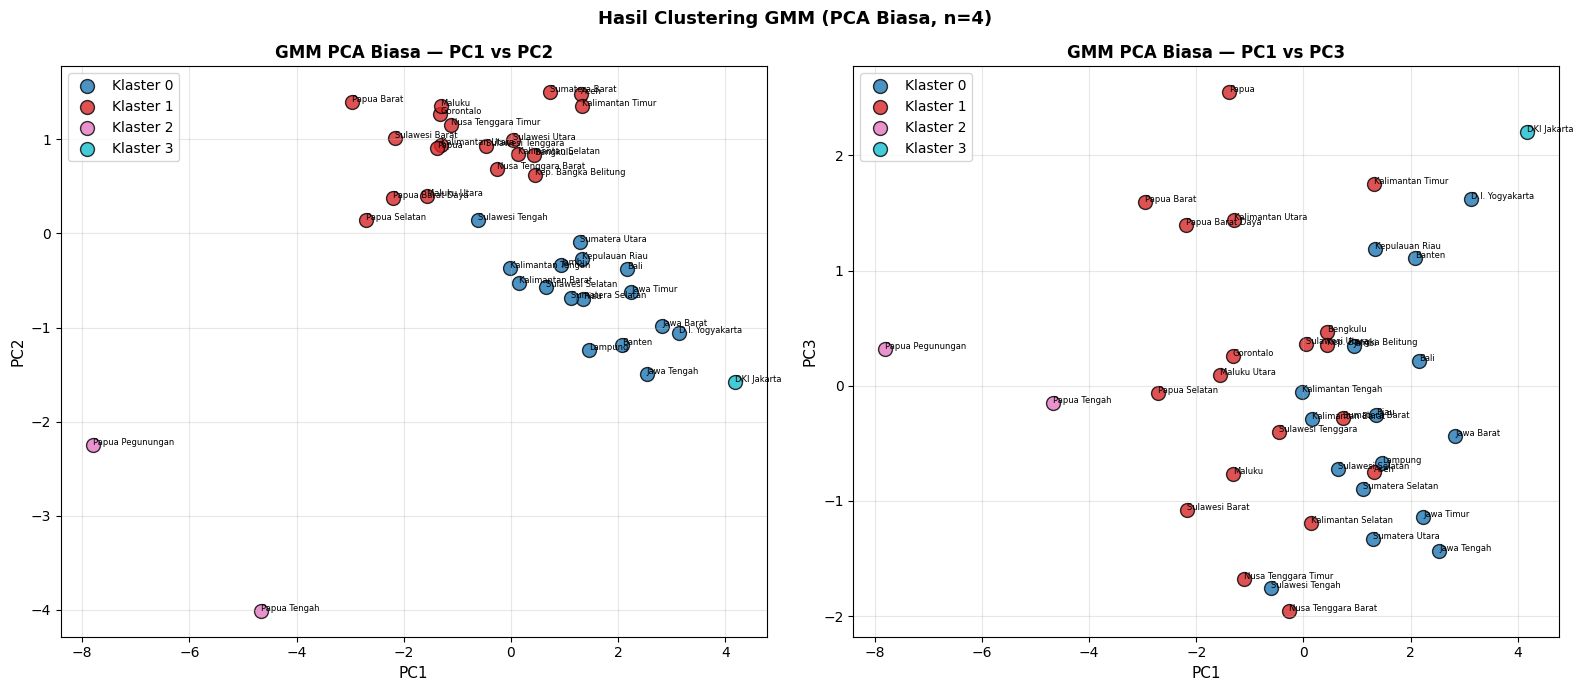

In [ ]:
# GMM Final dengan PCA biasa — n=4
n_opt_biasa = 4
gmm_pca_biasa = GaussianMixture(n_components=n_opt_biasa, random_state=42, n_init=10)
labels_gmm_pca_biasa = gmm_pca_biasa.fit_predict(X_pca)

df_hasil_gmm_pca_biasa = df.copy()
df_hasil_gmm_pca_biasa['Cluster_GMM'] = labels_gmm_pca_biasa

# Evaluasi
sil_gmm_biasa = silhouette_score(X_pca, labels_gmm_pca_biasa)
dbi_gmm_biasa = davies_bouldin_score(X_pca, labels_gmm_pca_biasa)
ch_gmm_biasa  = calinski_harabasz_score(X_pca, labels_gmm_pca_biasa)

print("=== GMM Final (PCA Biasa, n=4) ===")
print(f"Jumlah klaster       : {n_opt_biasa}")
print(f"Silhouette Score     : {sil_gmm_biasa:.4f}")
print(f"Davies-Bouldin Index : {dbi_gmm_biasa:.4f}")
print(f"Calinski-Harabasz    : {ch_gmm_biasa:.4f}")

print("\n=== Isi Klaster ===")
for cluster in sorted(df_hasil_gmm_pca_biasa['Cluster_GMM'].unique()):
    prov_list = df_hasil_gmm_pca_biasa[df_hasil_gmm_pca_biasa['Cluster_GMM'] == cluster]['Provinsi'].tolist()
    print(f"\nKlaster {cluster} ({len(prov_list)} provinsi):")
    for p in prov_list:
        print(f"  - {p}")

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
unique_labels = sorted(set(labels_gmm_pca_biasa))
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))
color_map = {label: colors[i] for i, label in enumerate(unique_labels)}

for label in unique_labels:
    mask = labels_gmm_pca_biasa == label
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=[color_map[label]], s=100, alpha=0.8,
                    edgecolors='black', label=f'Klaster {label}')
for i, prov in enumerate(df['Provinsi'].values):
    axes[0].annotate(prov, (X_pca[i, 0], X_pca[i, 1]), fontsize=6)
axes[0].set_xlabel('PC1', fontsize=11)
axes[0].set_ylabel('PC2', fontsize=11)
axes[0].set_title('GMM PCA Biasa — PC1 vs PC2', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

for label in unique_labels:
    mask = labels_gmm_pca_biasa == label
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 2],
                    c=[color_map[label]], s=100, alpha=0.8,
                    edgecolors='black', label=f'Klaster {label}')
for i, prov in enumerate(df['Provinsi'].values):
    axes[1].annotate(prov, (X_pca[i, 0], X_pca[i, 2]), fontsize=6)
axes[1].set_xlabel('PC1', fontsize=11)
axes[1].set_ylabel('PC3', fontsize=11)
axes[1].set_title('GMM PCA Biasa — PC1 vs PC3', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Hasil Clustering GMM (PCA Biasa, n=4)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
